# Import Libraries

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Load data

In [10]:
sales_train = pd.read_csv("E:/sales_predict/datasets/sales_train.csv")
items = pd.read_csv("E:/sales_predict/datasets/items.csv")
item_categories = pd.read_csv("E:/sales_predict/datasets/item_categories.csv")
shops = pd.read_csv("E:/sales_predict/datasets/shops.csv")
test = pd.read_csv("E:/sales_predict/datasets/test.csv")
sample_submission = pd.read_csv("E:/sales_predict/datasets/sample_submission.csv")

# Merging data

In [11]:
df = sales_train.merge(items, on='item_id', how='left')
df = df.merge(item_categories, on='item_category_id', how='left')
df = df.merge(shops, on='shop_id', how='left')
df.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
0,02.01.2013,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир"""
1,03.01.2013,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
2,05.01.2013,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
3,06.01.2013,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
4,15.01.2013,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум"""


# Feature Engineering

# Features depending on date

In [ ]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

### Year, week, month, day of week, weekend

We give the model an explicit understanding of information about a specific point in time because it will not be able to establish patterns if we simply leave the date attribute

In [ ]:
df['month'] = df['date'].dt.month          
df['year'] = df['date'].dt.year            
df['day_of_week'] = df['date'].dt.dayofweek  #(0-6)  
df['is_weekend'] = df['day_of_week'] > 4

### Cycle features

December is the 11th month and January is the 0th month, in this example it is clearly seen that the model will not understand that they are neighbors, so the months need to be transferred to an imaginary circle, where the sin values ​​will be the x values, and the cosine values ​​will be the y values, respectively.

In [ ]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

let's do the same for the days of the week and days

In [ ]:
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)  
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)  

In [ ]:
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)

### Lag and rolling statistics features

In [ ]:
df['lag_1'] = df.groupby(['shop_id', 'item_id'])['item_cnt_day'].shift(1)  
df['lag_3'] = df.groupby(['shop_id', 'item_id'])['item_cnt_day'].shift(3)  
df['lag_7'] = df.groupby(['shop_id', 'item_id'])['item_cnt_day'].shift(7)

In [ ]:
df['rolling_7_median'] = df.groupby(['shop_id', 'item_id'])['item_cnt_day'].transform(
            lambda x: x.rolling(7, min_periods=1).median())


In [ ]:
df['rolling_30_median'] = df.groupby(['shop_id', 'item_id'])['item_cnt_day'].transform(
            lambda x: x.rolling(30, min_periods=1).median())

## Groupping

In [ ]:
df['item_avg_sales'] = df.groupby(['item_id', 'month', 'shop_id'])['item_cnt_day'].transform('median')

In [ ]:
df['shop_avg_daily'] = df.groupby(['shop_id', 'day_of_week'])['item_cnt_day'].transform('median')

## logarifm feature

why do we need a logarithm at all?

It's simple, on some days sales skyrocketed due to the release of popular games, for example, a logarithm can partially solve this problem

In [ ]:
df['log_item_cnt_day'] = df['item_cnt_day'].apply(lambda x: np.log(x) if x > 0 else np.nan)

In [ ]:
df['log_item_cnt_day'].isna().sum()

7356

Let's handle negative item_cnt_day

since at the previous stage we found out that these are returns, then if we delete these 7000 corrupted lines, it will not greatly affect our data and model

In [ ]:
df = df[df['item_cnt_day'] > 0] 

In [ ]:
df['log_item_cnt_day'].isna().sum()

0

## City

In [ ]:
df['city'] = df['shop_name'].str.split().str[0]

In [ ]:
df['city'].unique()

array(['Химки', 'Цифровой', 'Чехов', 'Самара', 'Москва', 'Курск',
       'Адыгея', 'Якутск', 'Жуковский', 'Уфа', 'Калуга', 'Казань',
       'Вологда', 'Красноярск', 'Коломна', 'Воронеж', 'Интернет-магазин',
       'Балашиха', 'Волжский', 'Н.Новгород', 'Сергиев', 'Сургут', 'СПб',
       'Омск', 'Тюмень', 'РостовНаДону', 'Ярославль', 'Новосибирск',
       'Томск', 'Мытищи', 'Выездная'], dtype=object)

may be confusing digital and online store, but since these are separate categories and logically different places, then everything is fine

## Price changes

In [ ]:
df.sort_values(['item_id', 'date'], inplace=True)
df.loc[:, 'price_change'] = df.groupby('item_id')['item_price'].diff()
df.loc[:, 'price_increasing'] = (df['price_change'] > 0).astype(int)
df.groupby('item_id')['price_increasing'].transform(lambda x: x.fillna(0))
df.drop(columns=['price_change'], inplace=True)

In [ ]:
df['item_min_price'] = df.groupby('item_id')['item_price'].transform('min')
df['item_max_price'] = df.groupby('item_id')['item_price'].transform('max')

In [ ]:
df['price_range'] = df['item_max_price'] - df['item_min_price']

In [ ]:
df.columns

Index(['date', 'date_block_num', 'shop_id', 'item_id', 'item_price',
       'item_cnt_day', 'item_name', 'item_category_id', 'item_category_name',
       'shop_name', 'month', 'year', 'day_of_week', 'is_weekend', 'month_sin',
       'month_cos', 'dow_sin', 'dow_cos', 'day_sin', 'day_cos', 'lag_1',
       'lag_3', 'lag_7', 'rolling_7_mean', 'rolling_30_mean', 'item_avg_sales',
       'shop_avg_daily', 'log_item_cnt_day', 'price_increasing',
       'item_min_price', 'item_max_price', 'price_range', 'city'],
      dtype='object')

### Correlation

Text(0.5, 1.0, '')

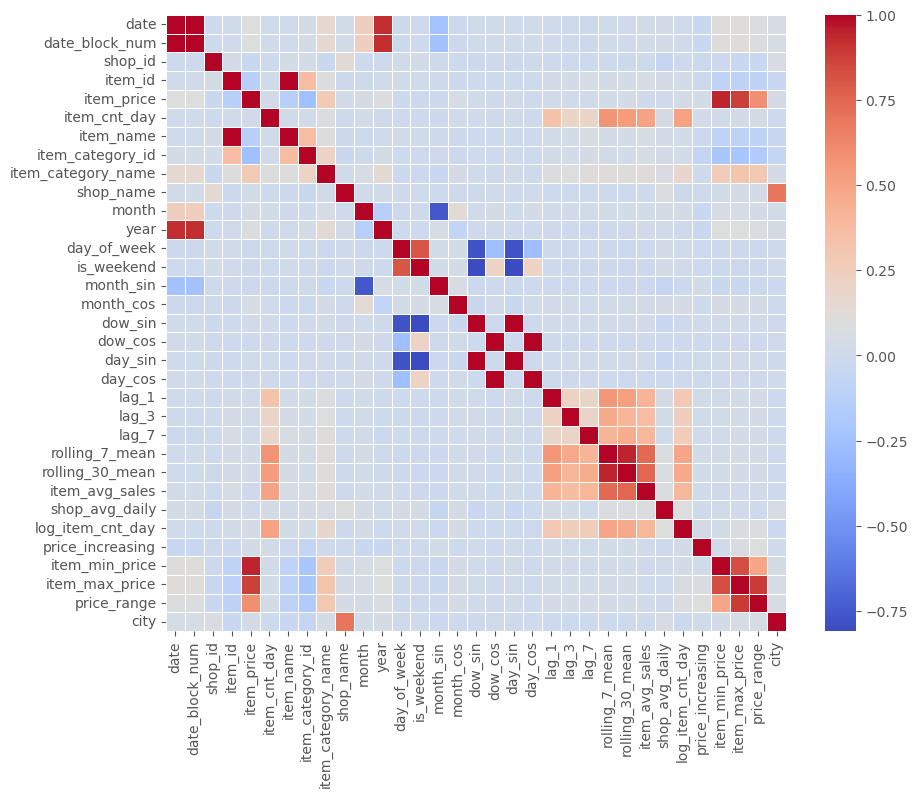

In [ ]:
df_numeric = df.copy()
for col in df.select_dtypes(include=['object']).columns:
    df_numeric[col] = pd.factorize(df[col])[0]

corr = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
           cmap='coolwarm',
           annot=False,
           cbar=True,   
           linewidths=0.7)

plt.title('Feature correlation', pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.title('')